In [1]:
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Getting forest loss data

In [2]:
loss_df = pd.read_csv("all_risk_at_loss.csv")
loss_df.head(10)

,longitude,latitude,risk_at_loss
0,94.222046,26.702871,0.595512
1,94.302895,26.702871,0.600705
2,94.308280,26.702871,0.036946
3,94.540050,26.702871,0.086094
4,94.545440,26.702871,0.086094
5,94.561610,26.702871,0.081611
6,94.588554,26.702871,0.078794
7,94.653240,26.702871,0.059904
8,94.785286,26.702871,0.060607
9,94.817630,26.702871,0.612173


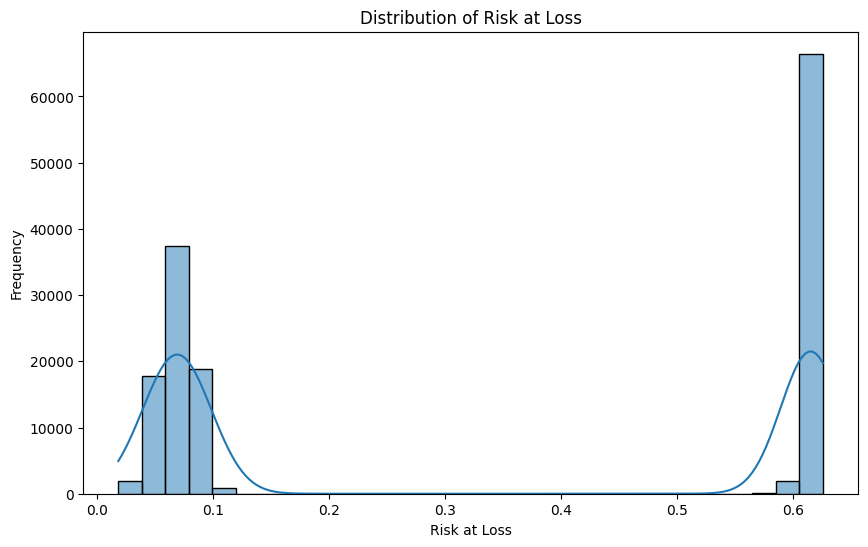

In [8]:
risk = loss_df["risk_at_loss"]
risk.head(10)

plt.figure(figsize=(10, 6))
sns.histplot(risk, bins=30, kde=True)
plt.title("Distribution of Risk at Loss")
plt.xlabel("Risk at Loss")
plt.ylabel("Frequency")
plt.show()

In [9]:
risk.max()

np.float64(0.6255247)

In [10]:
# Find the range of the latetudes and longitudes with risk between 0.58 and maximum risk
filtered_df = loss_df[(loss_df["risk_at_loss"] >= 0.58) & (loss_df["risk_at_loss"] <= risk.max())]
lat_range = (filtered_df["latitude"].min(), filtered_df["latitude"].max())
lon_range = (filtered_df["longitude"].min(), filtered_df["longitude"].max())
print(f"Latitude range: {lat_range}")
print(f"Longitude range: {lon_range}")

Latitude range: (np.float64(21.997496), np.float64(29.155272))
Longitude range: (np.float64(88.042534), np.float64(97.226906))


In [11]:
# find the mean lantitude and longitude of the places with risk between 0.58 and maximum risk based on frequency
mean_lat = filtered_df["latitude"].mean()
mean_lon = filtered_df["longitude"].mean()
print(f"Mean Latitude: {mean_lat}")
print(f"Mean Longitude: {mean_lon}")


Mean Latitude: 25.130228267654022
Mean Longitude: 93.11293471598584


# Loss

In [12]:
loss = pd.read_csv("all_loss.csv")
loss.head(10)

,Period,State,Total_Loss_Area_km2,.geo
0,2001-2005,Assam,398.826000,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,2001-2005,Manipur,242.346192,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2001-2005,Meghalaya,208.950386,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,2001-2005,Mizoram,236.770806,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,2001-2005,Nagaland,477.293488,"{""type"":""MultiPoint"",""coordinates"":[]}"
5,2001-2005,Sikkim,1.847128,"{""type"":""MultiPoint"",""coordinates"":[]}"
6,2001-2005,Tripura,106.122856,"{""type"":""MultiPoint"",""coordinates"":[]}"
7,2001-2005,Arunachal Pradesh,180.673618,"{""type"":""MultiPoint"",""coordinates"":[]}"
8,2006-2010,Assam,617.020609,"{""type"":""MultiPoint"",""coordinates"":[]}"
9,2006-2010,Manipur,265.122835,"{""type"":""MultiPoint"",""coordinates"":[]}"
